# TensorFlow Course from CodeBasics

## What is a neuron?

A neuron in an artificial neural network is a mathematical model that consists of a set of inputs, a set of weights,a bias and an activation function. For learning purpose, let us oversimplify it using an example.

Say you have to predict whether a person takes insurance based on their age, income and education. Mathematically, this can be approximated as:

$$
y = \sum_{i=1}^{n} w_i x_i + b
$$

where w(i) is the i-th weight, x(i) is the i-th independent variable and b is the bias. Graphically, we just drew a line of best fit through the points to be able to predict whether a person will take insurance based on the independent variables.

By drawing this line of best fit, which is basically **logistic regression**, we were able to get values of w(i) and b which help us predict y given a set of values x(i), with satisfactory accuracy.

This line of best fit however may not suitably represent the relationship between y and x(i) (for example when it is a classification problem, the graph will jump suddenly as from a certain threshold).

To draw a better curve of best fit, we use an **activation function**, that is above a certain threshold of **y**, the person will take insurance while below that threshold, he will not take insurance. One example of an activation function that we may use is the **sigmoid function**, also known as the **logit function**. The sigmoid function is given by:

$$
\text{sigmoid}(y) = \frac{1}{1 + e^{-y}}
$$

Overall, given our set of inputs x(i), we will calculate y and then use our sigmoid function to know whether this y leads to the person getting insurance (sigmoid(y) > threshold) or not getting insurance (sigmoid(y) <= throshold). That which has just been described is a neuron!

$$
(\text{age},\ \text{income},\ \text{education})
\;\longrightarrow\;
\underset{\Large \text{neuron}}{
\left(
y = \sum_{i=1}^{n} w_i x_i + b \;\middle|\;
z = \frac{1}{1 + e^{-y}}
\right)
}
\;\longrightarrow\;
0 \leq z \leq 1
$$

### Sigmoid function

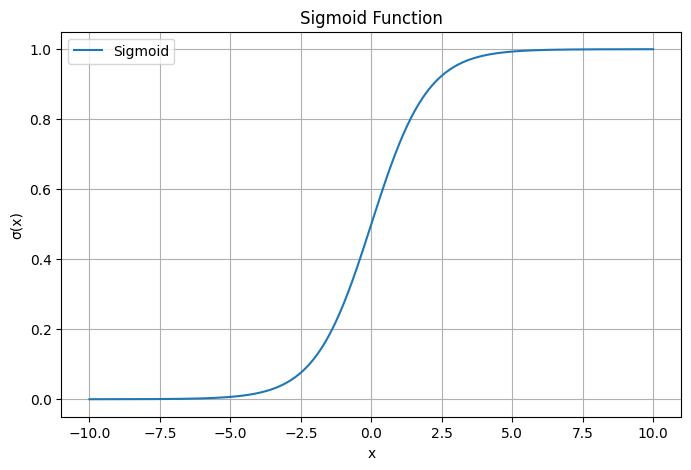

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)
y = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8,5))
plt.plot(x, y, label='Sigmoid')
plt.xlabel("x")
plt.ylabel("σ(x)")
plt.title("Sigmoid Function")
plt.grid(True)
plt.legend()
plt.show()

## What is Keras?

Keras was invented as a wrapper for tensorflow, CNTK and theano to make deep learning code simpler. As from TensorFlow 2.0, it has been integrated in the TensorFlow framework itself. 

It has been created for convenience. It is as simple as that.

## Activation Functions

As we have seen, activation functions are helpful in the output layer. For example in binary classification problem, the neuron in the output layer 'firing' may imply that a label is met and it not firing may imply the other label is met. An example of an activation function used in the output layer is the sigmoid function.

However, how are activation functions used in hidden layers?

Consider a neural network with at least 1 hidden layer. The neurons in each hidden layer use an activation function. So each of them apply an activation function on the linear combination of the 'inputs' provided from the previous layer. Say, we remove the activation function for all hidden layers. In this case, the neuron of each hidden layer will only compute a linear combination of the 'inputs' provided by the previous layer. Hence the end result produced at the output layer will only a linear combination of the inputs to the input layer. 

The same result could have been achieved by not using any hidden layers!

**So not using activation functions make the hidden layers totally useless!!**

Most complex problems in real life cannot be simply solved by linear equations. Activation functions help build these non-linear equations.

### Step Function

The simplest (and most useless) example of an activation function is the **step function**. It is shown in the code below.

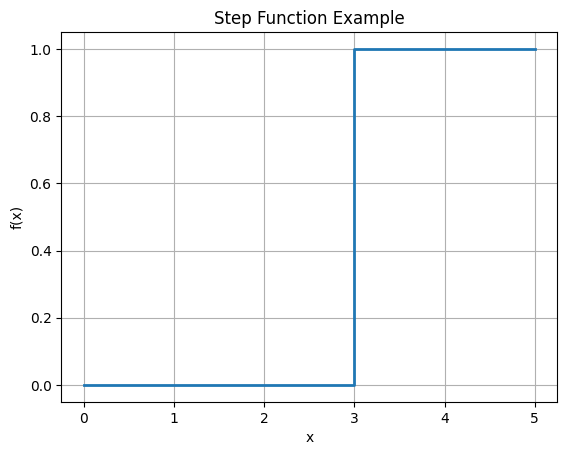

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (step function values)
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 0, 0, 1, 1, 1])

# Create step plot
plt.step(x, y, where='post', linewidth=2)

# Optional styling
plt.title("Step Function Example")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)

plt.show()

A neuron using the step activation function ALWAYS returns either 0 or 1, as we can see in the above graph. The function is discrete.

The step function easily misclassifies some data points.

The second problem with the step function is **multi-class classification**. The step function will always return either 0 or 1. If we look at the MNIST example problem, where we have 10 possible outputs, we will not be able to uniquely identify the output label based on the output of the neurons in the output layer, as we can get a 0 or 1 for more than 2 digits.

### Sigmoid or Logit Function

The sigmoid function, unlike the step function, can return ANY value between 0 and 1 inclusive. Unlike the step function, it is continuous on the interval [0,1].

That is why we were able to use the sigmoid function as the activation function for our output layer in the MNIST problem. The higher the number output by a neuron in the output layer, the greater the probability that would be generated by the softmax function and hence the higher chance that the label of this output layer neuron is our actual digit input to the neural network.

For **binary classification**, it is generally recommended to use sigmoid in the output layer.

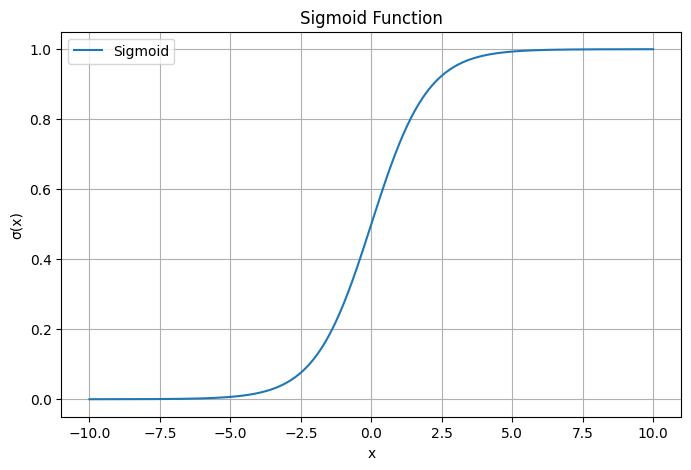

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)
y = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8,5))
plt.plot(x, y, label='Sigmoid')
plt.xlabel("x")
plt.ylabel("σ(x)")
plt.title("Sigmoid Function")
plt.grid(True)
plt.legend()
plt.show()

### The tanh function

It is similar to the sigmoid function but instead of giving a range of [0,1], it gives a range of (-1,1).

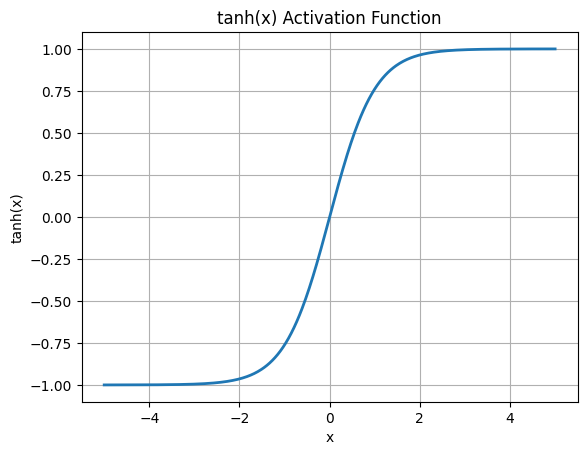

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Input range
x = np.linspace(-5, 5, 500)

# tanh activation function
y = np.tanh(x)

# Plot
plt.plot(x, y, linewidth=2)

# Styling
plt.title("tanh(x) Activation Function")
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.grid(True)

plt.show()

The tanh function is usually used in layers except for the output layer *(need to research on this)*.

### The issues with the sigmoid function and the tanh function

In the gradient descent algorithm, you need to calculate the derivative of your activation function and use them to backpropagate your errors. However, for both the sigmoid function and the tanh function, the derivate for small and large values are nearly 0, as we can decipher by their graphs.

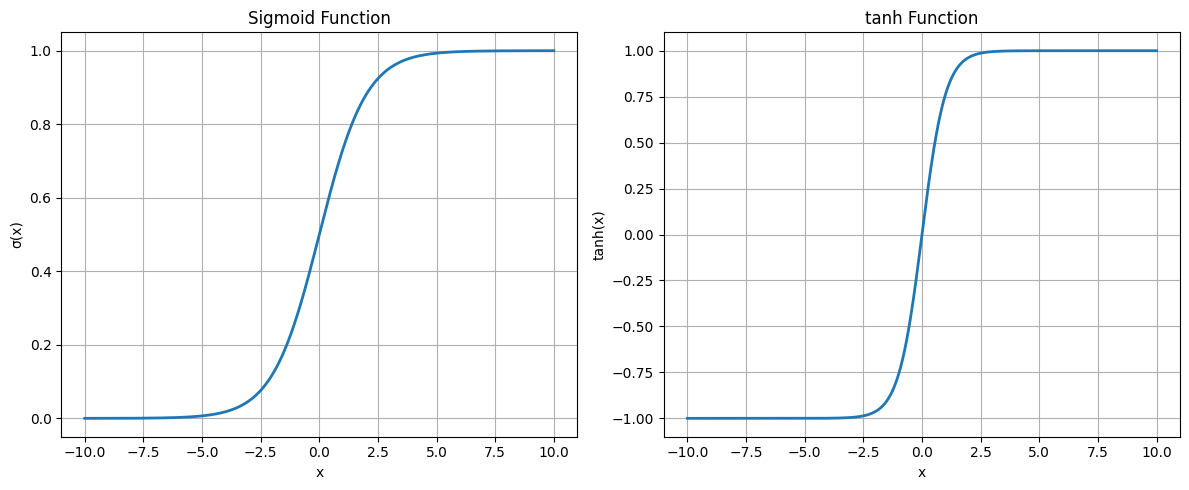

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Input range
x = np.linspace(-10, 10, 500)

# Activation functions
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sigmoid plot
axes[0].plot(x, sigmoid, linewidth=2)
axes[0].set_title("Sigmoid Function")
axes[0].set_xlabel("x")
axes[0].set_ylabel("σ(x)")
axes[0].grid(True)

# Tanh plot
axes[1].plot(x, tanh, linewidth=2)
axes[1].set_title("tanh Function")
axes[1].set_xlabel("x")
axes[1].set_ylabel("tanh(x)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Due to these near-zero gradients, the learning of the Neural Network becomes very, very slow. This is called the **vanishing gradient problem**.


To solve this problem, we came up with the **relu function**.

### The ReLu Function

The Relu function is basically:

$$
\text{ReLU}(z) = \max(0, z)
$$

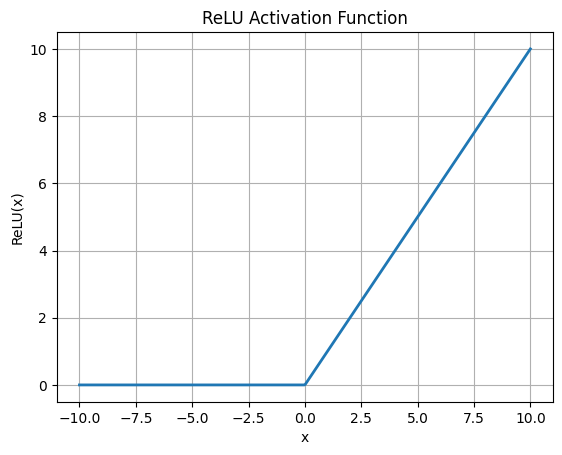

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Input range
x = np.linspace(-10, 10, 500)

# ReLU function
relu = np.maximum(0, x)

# Plot
plt.plot(x, relu, linewidth=2)

# Styling
plt.title("ReLU Activation Function")
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.grid(True)

plt.show()

Basically, if our input is less than or equal to 0, the output is 0. If our input is greater than 0, our output is zero.

>**THE GUIDELINE IS: FOR HIDDEN LAYERS, IF YOU ARE UNSURE WHICH ACTIVATION FUNCTION TO USE, JUST USE ReLU AS YOUR DEFAULT CHOICE**

Given the simplicity of the function, it is very computationally inexpensive.

ReLU also has the vanishing gradient problem for inputs less than 0. Hence to solve that problem we have the **Leaky ReLU**

## Leaky ReLU

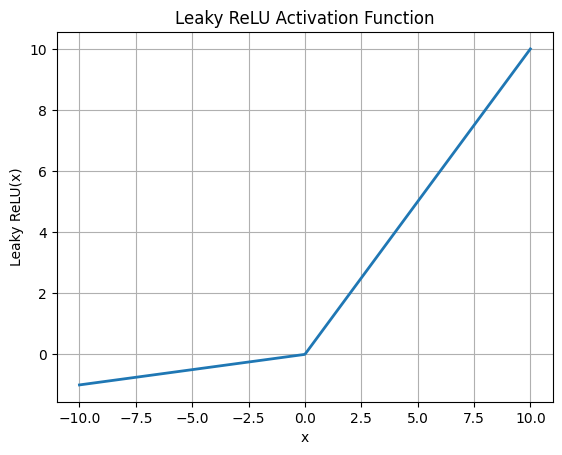

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Input range
x = np.linspace(-10, 10, 500)

# Leaky ReLU parameter (small slope for negative values)
alpha = 0.1

# Leaky ReLU function
leaky_relu = np.where(x > 0, x, alpha * x)

# Plot
plt.plot(x, leaky_relu, linewidth=2)

# Styling
plt.title("Leaky ReLU Activation Function")
plt.xlabel("x")
plt.ylabel("Leaky ReLU(x)")
plt.grid(True)

plt.show()

In Leaky ReLU, we are trying to remove the zero gradient for input values less than 0. The equation can be the following for example:

$$
\text{Leaky ReLU}(z) = \max(0.1z, z)
$$

### Summary of Activation Function

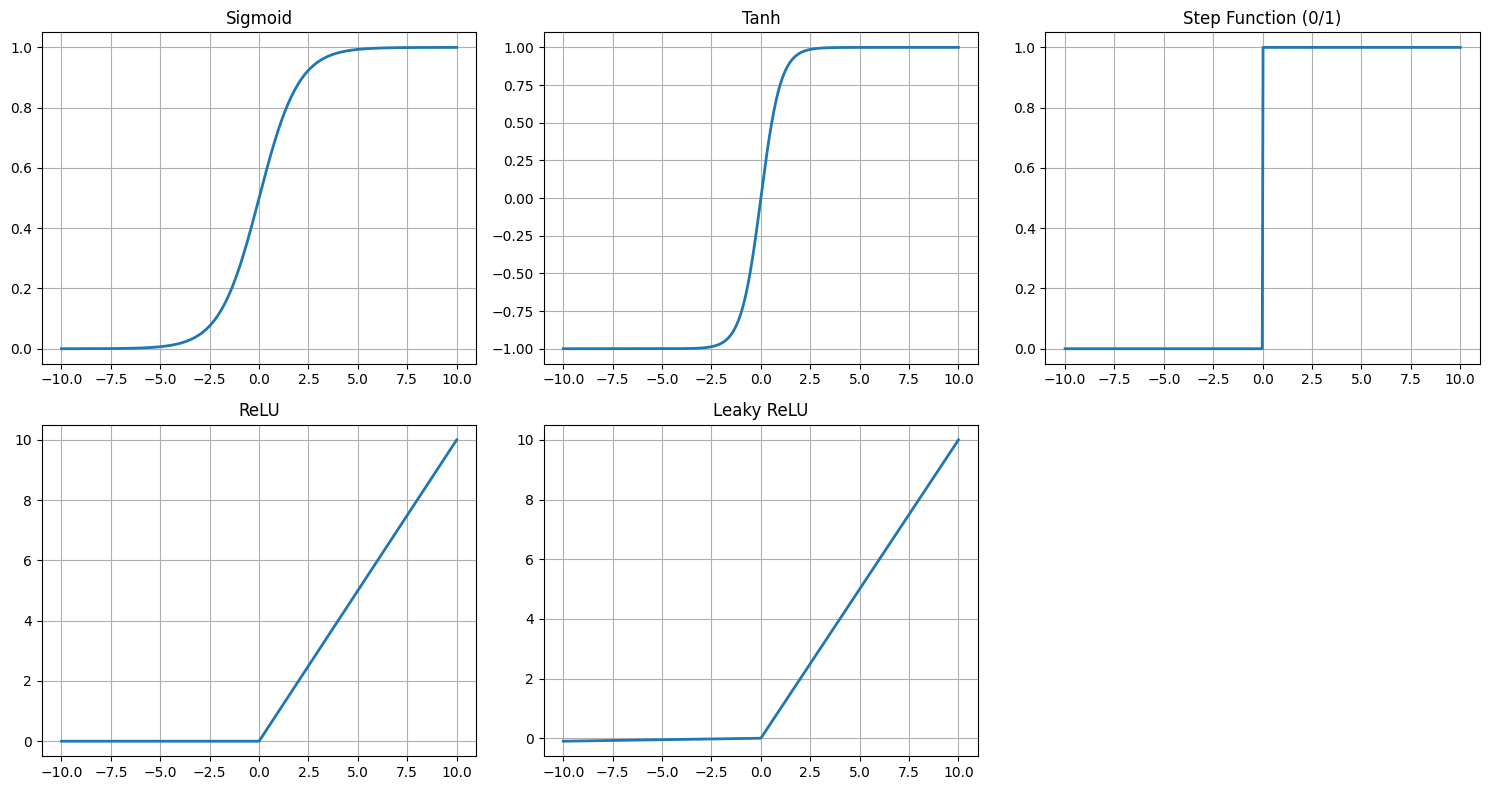

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Input range
x = np.linspace(-10, 10, 500)

# Activation functions
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

alpha = 0.01
leaky_relu = np.where(x > 0, x, alpha * x)

# Step function (Heaviside)
step = np.where(x >= 0, 1, 0)

# Create subplots (2x3 grid)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Sigmoid
axes[0, 0].plot(x, sigmoid, linewidth=2)
axes[0, 0].set_title("Sigmoid")
axes[0, 0].grid(True)

# Tanh
axes[0, 1].plot(x, tanh, linewidth=2)
axes[0, 1].set_title("Tanh")
axes[0, 1].grid(True)

# Step function
axes[0, 2].plot(x, step, linewidth=2)
axes[0, 2].set_title("Step Function (0/1)")
axes[0, 2].grid(True)

# ReLU
axes[1, 0].plot(x, relu, linewidth=2)
axes[1, 0].set_title("ReLU")
axes[1, 0].grid(True)

# Leaky ReLU
axes[1, 1].plot(x, leaky_relu, linewidth=2)
axes[1, 1].set_title("Leaky ReLU")
axes[1, 1].grid(True)

# Empty last subplot (optional cleanup)
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

The choice of which activation function to use is not always clear. 

- For binary classification problems, we would most likely use the sigmoid function in the output layer.
- For the hidden layers, we would most likely use ReLU or Leaky ReLU.

## Loss or Cost Functions

Loss functions are used to calculate the loss between the actual value and the predicted value. Different loss functions relate to different mathematical formulae used to calculate the loss. Example of loss functions are:

- Sparse Categorical Crossentropy
- Binary Crossentropy
- Categorical Crossentropy
- Mean Absolute Error
- Mean Squared Error

*NOTE: Individual errors are called losses while the aggregated error is called the cost.*

---

### Mean Absolute Error

The formula for mean absolute error is:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

We use MAE for:

- linear regression
- care about average error magnitude, not large penalties
- data with outliers(MAE is more robust)

Difference from MSE:

- MSE heavily punishes big mistakes
- MAE treats all errors linearly

Trade-off:

- MAE is more stable but harder to optimize (gradient is constant)

It is a bad choice for:

- Classification problems/logistic regression

---

### Mean Squared Error

The formula for mean squared error is:

$$
\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

We use MSE for:

- linear regression problems
- penalizing large errors more than small ones (because of squaring)

It is a bad choice for:

- Classification problems(it treats classes like numbers which is wrong)

---

### Binary Crossentropy or Log Loss

The formula for binary crossentropy is:

$$
\text{Binary Crossentropy}
= -\frac{1}{n}\sum_{i=1}^{n}
\left[
y_i \log(p_i) + (1 - y_i)\log(1 - p_i)
\right]
$$

**Where**

$$
n = \text{number of samples}
$$

$$
i = \text{index of a sample, } i = 1,2,\dots,n
$$

$$
y_i \in \{0,1\} = \text{true binary label for sample } i
$$

$$
p_i \in (0,1) = \text{predicted probability that sample } i \text{ belongs to class } 1
$$

$$
\log = \text{natural logarithm (base } e \text{)}
$$

It is used for:

- Binary Classification (two classes only)
- Output layer is 1 neuron with sigmoid
- Output probability of class 1

Example use cases:

- spam v/s not spam
- disease v/s no disease
- yes/no predictions

Why it works:

- Directly models probability mismatch
- Strongly penalizes confident wrong predictions

---

### Categorical Crossentropy

The formula for categorical crossentropy is:

$$
\text{Categorical Crossentropy}
= -\frac{1}{n}\sum_{i=1}^{n}\sum_{k=1}^{K}
y_{i,k}\log(p_{i,k})
$$

**where**

$$
n = \text{number of samples}
$$

$$
i = \text{index of a sample, } i = 1,2,\dots,n
$$

$$
K = \text{number of classes}
$$

$$
k = \text{class index, } k = 1,2,\dots,K
$$

$$
y_{i,k} \in \{0,1\} = \text{one-hot encoded true label for sample } i \text{ and class } k
$$

$$
p_{i,k} \in (0,1) = \text{predicted probability that sample } i \text{ belongs to class } k
$$

$$
\log = \text{natural logarithm (base } e \text{)}
$$

It should be used:

- For multi-class classification (one correct class)
- When the output layer uses softmax over K classes
- When labels are one-hot encoded

Typical use cases:

- digit recognition
- object classification(cat,dog,bird)

Key idea:

- Compares full probability distribution v/s true class distribution

---

### Sparse Categorical Crossentropy

The formula for sparse categorical crossentropy is:
$$
\text{Sparse Categorical Crossentropy}
= -\frac{1}{n}\sum_{i=1}^{n}\log\left(p_{i, y_i}\right)
$$

**Where**

$$
n = \text{number of samples}
$$

$$
i = \text{index of a sample, } i = 1,2,\dots,n
$$

$$
y_i \in \{0,1\} = \text{true binary label for sample } i
$$

$$
p_i \in (0,1) = \text{predicted probability that } y_i = 1
$$

$$
\log = \text{natural logarithm (base } e \text{)}
$$

It is the same as categorical crossentropy, but with a different label format.

It is used when:

- we have multi-class definitions
- but labels are **integers** instead of one-hot vectors

Example:

- label = 3 instead of [0,0,0,1,0]

It is useful as:

- saves memory
- easier preprocessing

Internally, it behaves exactly like categorical crossentropy

---

### Sparse Categorical Crossentropy vs Categorical Crossentropy (Use Cases)

The difference is only in how labels are represented, not in the underlying idea.



#### 1. Categorical Crossentropy (One-Hot Labels)

##### Use case: Image classification (10 classes: digits 0–9)

You use this when labels are **one-hot encoded vectors**.

##### Dataset format

| Image     | Label (one-hot)                  |
|----------|----------------------------------|
| image_1  | [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]   |
| image_2  | [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]   |
| image_3  | [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]   |

##### Model output (softmax)

$$
[0.1,\ 0.05,\ 0.7,\ 0.02,\ \dots]
$$

##### Loss function
- Categorical Crossentropy

##### When to use
- Labels already converted to one-hot vectors
- Multi-class problems with explicit vector encoding



#### 2. Sparse Categorical Crossentropy (Integer Labels)

##### Use case: Same image classification task (10 classes)

You use this when labels are **integer encoded**.

##### Dataset format

| Image     | Label (integer) |
|----------|-----------------|
| image_1  | 2               |
| image_2  | 5               |
| image_3  | 0               |

##### Model output (softmax)

$$
[0.1,\ 0.05,\ 0.7,\ 0.02,\ \dots]
$$

##### Loss function
- Sparse Categorical Crossentropy

##### When to use
- Labels stored as integers
- Default choice in most modern pipelines (e.g., TensorFlow/Keras)
- Large number of classes where one-hot encoding is inefficient



#### Summary

| Loss Function                     | Label Format        | Example Label |
|----------------------------------|---------------------|--------------|
| Categorical Crossentropy         | One-hot vector      | [0,0,1,0,...] |
| Sparse Categorical Crossentropy  | Integer class index  | 2, 5, 0       |



#### Practical takeaway

If you are unsure:
- Use **Sparse Categorical Crossentropy**
- Only switch to categorical if your pipeline already uses one-hot encoding